# 11 - Dashboard MVP

## Objetivo
- Proveer un estimador interactivo con intervalos de incertidumbre.
- Mostrar capas de mapa: anuncios, barrios, clusters, oportunidades.
- Incluir comparadores (percentiles y SERPAVI manual).

## Flujo general
- Cargar dataset procesado, features y modelo.
- Preparar controles UI (sliders + toggles por variable).
- Estimar precio + intervalo y explicar drivers.
- Renderizar mapas y comparadores basicos.

## Inputs esperados
- `artifacts/processed_rent.*`
- `artifacts/features_master.parquet`
- `models/best_model.joblib` (legacy) o `models/best_models.joblib` (dual-target)
- `models/quantile_models.joblib` (dual-target: {price: {...}, price_m2: {...}})
- `artifacts/barriosMadrid.json` (opcional)
- `artifacts/clusters.csv` (opcional)
- `reports/opportunities_top.csv` (opcional)

## Outputs/artefactos
- Widget interactivo en notebook.
- Mapas con capas de anuncios y contexto.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd

# =====================================================================
# Configuracion base y reproducibilidad
# =====================================================================
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Localiza la raiz del repositorio buscando .git o pyproject.toml."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# align_X_to_model: reordena las columnas de X para que coincidan con
# las features que espera el modelo (mismo orden y nombres).
# plot_maps: genera mapas interactivos con folium.
from src.utils import align_X_to_model, plot_maps


In [2]:
import joblib
from src.utils import plot_maps
import importlib.util

# =====================================================================
# 1. Cargar datos procesados y modelo entrenado
# =====================================================================
processed_path = ROOT / "artifacts" / "processed_rent.parquet"
if processed_path.exists():
    df = pd.read_parquet(processed_path)
else:
    df = pd.read_csv(ROOT / "artifacts" / "processed_rent.csv.gz")

features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    features_df = pd.read_parquet(features_path)
else:
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        features_df = pd.read_parquet(core_path)
    else:
        features_df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

# Cargar modelo (preferencia dual-target si existe)
#   1. models/best_models.joblib (dual-target)
#   2. models/best_model.joblib (legacy)
model_path_dual = ROOT / "models" / "best_models.joblib"
model_path_legacy = ROOT / "models" / "best_model.joblib"

if model_path_dual.exists():
    _raw_model = joblib.load(model_path_dual)
else:
    _raw_model = joblib.load(model_path_legacy)

if isinstance(_raw_model, dict):
    if "price" in _raw_model and isinstance(_raw_model["price"], dict):
        _price_artifact = _raw_model["price"]
        model = _price_artifact["model"]
        print("Modelo dual-target cargado (target operativo del dashboard: price)")
        if "cv_mae" in _price_artifact:
            print(f"  CV MAE: {_price_artifact['cv_mae']:.2f}")
        if "holdout_mae" in _price_artifact:
            print(f"  Holdout MAE: {_price_artifact['holdout_mae']:.2f}")
    elif "model" in _raw_model:
        model = _raw_model["model"]
        print(f"Modelo legacy cargado: {_raw_model.get('boosting_engine', 'unknown')} "
              f"(CV MAE: {_raw_model.get('cv_mae', '?'):.2f}, "
              f"Holdout MAE: {_raw_model.get('holdout_mae', '?')})")
    else:
        raise ValueError(f"Formato de modelo no reconocido: keys={list(_raw_model.keys())}")
else:
    model = _raw_model

# Cargar modelos cuantilicos para intervalos de prediccion (si existen)
quantile_payload = None
quantile_path = ROOT / "models" / "quantile_models.joblib"
if quantile_path.exists():
    _raw_quantile = joblib.load(quantile_path)
    if isinstance(_raw_quantile, dict) and "price" in _raw_quantile and isinstance(_raw_quantile["price"], dict):
        quantile_payload = _raw_quantile["price"]
        print("Quantile models cargados (dual-target, usando target=price)")
    else:
        quantile_payload = _raw_quantile
        print("Quantile models cargados (formato legacy)")

# =====================================================================
# 2. Preparar features sin leakage
# =====================================================================
from src.utils import get_feature_cols
feature_cols = get_feature_cols(features_df, numeric_only=True)
X = features_df[feature_cols]

X = X.replace([np.inf, -np.inf], np.nan)
feature_medians = X.median(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0)

# Alinear X a las features del modelo (mismo orden y columnas)
from src.utils import align_X_to_model
X = align_X_to_model(X, model)
feature_medians = X.median(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0)

# Medianas por distrito (para que el selector de distrito afecte la prediccion)
# Cuando el usuario selecciona un distrito, las features numéricas toman
# los valores tipicos de ese distrito (distance_center_km, density_1km, etc.)
district_medians = {}
district_col = "district" if "district" in features_df.columns else None
if district_col:
    for dist_name, group in features_df.groupby(district_col):
        dist_X = group[X.columns].replace([np.inf, -np.inf], np.nan)
        district_medians[dist_name] = dist_X.median().replace([np.inf, -np.inf], np.nan).fillna(0)

# Importancias globales (para ordenar features en el widget)
importances = None
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X.columns)
elif hasattr(model, "named_steps") and hasattr(model.named_steps.get("model", None), "feature_importances_"):
    importances = pd.Series(model.named_steps["model"].feature_importances_, index=X.columns)
else:
    importances = X.var().sort_values(ascending=False)
global_importances = importances.sort_values(ascending=False)

# =====================================================================
# 3. Cargar capas adicionales (barrios, clusters, oportunidades)
# =====================================================================
barrios_path = ROOT / "artifacts" / "barriosMadrid.json"
barrios_df = None
if barrios_path.exists():
    try:
        barrios = json.loads(barrios_path.read_text(encoding="utf-8"))
        barrios_df = pd.DataFrame(barrios)
    except Exception:
        barrios_df = None

clusters_path = ROOT / "artifacts" / "clusters.csv"
if clusters_path.exists():
    clusters_df = pd.read_csv(clusters_path)
    for id_col in ["id", "url", "listing_fingerprint"]:
        if id_col in df.columns and id_col in clusters_df.columns:
            df = df.merge(clusters_df, on=id_col, how="left")
            break

opps_path = ROOT / "reports" / "opportunities_top.csv"
opps_df = None
if opps_path.exists():
    try:
        opps_df = pd.read_csv(opps_path)
    except Exception:
        opps_df = None

# =====================================================================
# 4. Funcion de prediccion con intervalo de confianza
# =====================================================================
def predict_with_interval(input_row: dict):
    """Predice precio puntual + intervalo P5-P95 calibrado con CQR."""
    input_df = pd.DataFrame([input_row]).reindex(columns=X.columns)
    pred = model.predict(input_df)[0]
    low = high = None
    lo_q = hi_q = None
    if quantile_payload:
        q_models = quantile_payload.get("models", {})
        q_features = quantile_payload.get("features", list(X.columns))
        quantile_levels = quantile_payload.get("quantile_levels", [0.05, 0.5, 0.95])
        lo_q, hi_q = min(quantile_levels), max(quantile_levels)
        input_q = input_df.reindex(columns=q_features).fillna(0)
        if lo_q in q_models and hi_q in q_models:
            low = q_models[lo_q].predict(input_q)[0]
            high = q_models[hi_q].predict(input_q)[0]
            low, high = min(low, high), max(low, high)
            best_method = quantile_payload.get("best_method", "raw")
            if best_method == "log":
                conformal_log = quantile_payload.get("conformal_log")
                if conformal_log and conformal_log.get("qhat") is not None:
                    qhat_log = float(conformal_log.get("qhat"))
                    if np.isfinite(qhat_log):
                        low_log = np.log1p(np.clip(low, a_min=0, a_max=None))
                        high_log = np.log1p(np.clip(high, a_min=0, a_max=None))
                        low = np.expm1(low_log - qhat_log)
                        high = np.expm1(high_log + qhat_log)
                        low = max(0, low)
            else:
                conformal = quantile_payload.get("conformal")
                if conformal and conformal.get("qhat") is not None:
                    qhat = float(conformal.get("qhat"))
                    if np.isfinite(qhat):
                        low -= qhat
                        high += qhat
                        low = max(0, low)
    return pred, low, high, lo_q, hi_q

# =====================================================================
# 5. Funciones auxiliares para la UI
# =====================================================================
def _is_ui_excluded(col: str) -> bool:
    col_l = col.lower()
    if col_l in {"web_id", "id", "url", "title", "listing_fingerprint"}:
        return True
    if col_l.startswith("log_"):
        return True
    if col_l in {"lat", "lng", "lon"}:
        return True
    return False


def explain_input(input_row: dict, used_cols: list[str] | None = None):
    """Genera explicacion de los drivers de la prediccion."""
    try:
        import shap
        input_df = pd.DataFrame([input_row]).reindex(columns=X.columns).fillna(0)
        explainer = shap.Explainer(model)
        shap_values = explainer(input_df)
        top_pos = shap_values.values[0].argsort()[-3:][::-1]
        top_neg = shap_values.values[0].argsort()[:3]
        explanation = "Sube por: " + ", ".join(input_df.columns[top_pos])
        explanation += ". Baja por: " + ", ".join(input_df.columns[top_neg])
        return explanation
    except Exception:
        pass

    explain_feats = [c for c in global_importances.index if not _is_ui_excluded(c)]
    if used_cols:
        explain_feats = [c for c in explain_feats if c in used_cols]
    top_feats = explain_feats[:5] if explain_feats else list(global_importances.index[:5])
    narrative = []
    for feat in top_feats:
        value = input_row.get(feat, feature_medians.get(feat, 0))
        median = feature_medians.get(feat, value)
        direction = "sube" if value >= median else "baja"
        narrative.append(f"{direction} por {feat}")
    return "; ".join(narrative) if narrative else "Explicacion basada en medianas del dataset."

# =====================================================================
# 6. Widget interactivo: estimador de precio con sliders
# =====================================================================
if importlib.util.find_spec("ipywidgets"):
    import ipywidgets as widgets
    from IPython.display import display

    # Inputs visibles para usuario final: intuitivos y accionables.
    preferred_cols = [
        "surface_m2",
        "bedrooms",
        "bathrooms",
        "year_built",
    ]
    feature_cols = [c for c in preferred_cols if c in X.columns and not _is_ui_excluded(c)]

    _int_features = {"bedrooms", "bathrooms", "year_built"}

    sliders = {}
    toggles = {}
    control_map = {}
    ui_rows = []

    for i, col in enumerate(feature_cols):
        finite_vals = X[col].replace([np.inf, -np.inf], np.nan).dropna()
        if finite_vals.empty:
            continue
        min_val = float(finite_vals.min())
        max_val = float(finite_vals.max())
        if not np.isfinite(min_val) or not np.isfinite(max_val) or min_val == max_val:
            continue

        if col in _int_features:
            int_min = int(min_val)
            int_max = int(max_val)
            if col == "year_built":
                int_min = 1900
                int_max = max(int_max, 1900)
            default_val = int(feature_medians.get(col, finite_vals.median()))
            default_val = min(max(default_val, int_min), int_max)
            slider = widgets.IntSlider(
                value=default_val,
                min=int_min,
                max=int_max,
                description=col,
            )
        else:
            slider = widgets.FloatSlider(
                value=float(feature_medians.get(col, finite_vals.median())),
                min=min_val,
                max=max_val,
                description=col,
            )
        toggle = widgets.Checkbox(value=False, description="usar")
        val_key = f"v_{i}"
        use_key = f"u_{i}"
        sliders[val_key] = slider
        toggles[use_key] = toggle
        control_map[col] = (val_key, use_key)
        ui_rows.append(widgets.HBox([toggle, slider]))

    district_options = sorted(df["district"].dropna().unique()) if "district" in df.columns else ["N/A"]
    district_widget = widgets.Dropdown(options=["(seleccionar)"] + list(district_options), description="Distrito:")
    ui_rows.insert(0, district_widget)

    def predict(**kwargs):
        """Callback del widget: calcula prediccion y muestra resultado."""
        # Base: medianas globales
        row = feature_medians.to_dict()
        used_cols = []

        # Incorporar distrito: sobreescribir features con medianas del distrito
        district_sel = kwargs.get("district_sel", "(seleccionar)")
        if district_sel != "(seleccionar)" and district_sel in district_medians:
            dist_med = district_medians[district_sel]
            for c in X.columns:
                row[c] = dist_med.get(c, row.get(c, 0))

        # Aplicar sliders (sobreescriben el distrito para las features activas)
        for col, (val_key, use_key) in control_map.items():
            if kwargs.get(use_key, False):
                row[col] = kwargs.get(val_key, row.get(col))
                used_cols.append(col)

        pred, low, high, lo_q, hi_q = predict_with_interval(row)
        narrative = explain_input(row, used_cols=used_cols)
        if low is not None and high is not None:
            lo_lbl = int(round((lo_q or 0.05) * 100))
            hi_lbl = int(round((hi_q or 0.95) * 100))
            print(f"Prediccion estimada: {pred:.2f} EUR/mes (P{lo_lbl}={low:.2f}, P{hi_lbl}={high:.2f})")
        else:
            print(f"Prediccion estimada: {pred:.2f} EUR/mes")
        if district_sel != "(seleccionar)":
            print(f"Distrito: {district_sel}")
        if used_cols:
            print(f"Explicacion: {narrative}")
        else:
            print("Explicacion: sin variables activas; usando medianas.")

    controls = {}
    controls.update(sliders)
    controls.update(toggles)
    controls["district_sel"] = district_widget

    ui = widgets.VBox(ui_rows)
    out = widgets.interactive_output(predict, controls)
    display(ui, out)
else:
    print("Widgets no disponibles. Mostrar resultados en formato tabla.")

Modelo dual-target cargado (target operativo del dashboard: price)
  CV MAE: 391.48
  Holdout MAE: 301.31
Quantile models cargados (dual-target, usando target=price)


Output()

In [3]:
# =====================================================================
# Comparadores basicos: percentiles globales de precio
# =====================================================================
# Muestran el rango general de precios en el dataset completo.
# P10 = precio barato, P50 = precio tipico, P90 = precio alto.
# Util para contextualizar cualquier prediccion del estimador.
if "price" in df.columns:
    percentiles = df["price"].quantile([0.1, 0.5, 0.9])
    print("Percentiles precio:", percentiles.to_dict())


Percentiles precio: {0.1: 850.0, 0.5: 1450.0, 0.9: 3550.0}


In [4]:
# =====================================================================
# Comparador por percentiles de distrito
# =====================================================================
# Tabla estadistica que muestra para cada distrito:
#   - count: numero de anuncios
#   - mean/std: media y desviacion tipica del precio
#   - P10, P25, P50, P75, P90: percentiles del precio
# Esto permite al usuario comparar su prediccion con el rango
# habitual de su zona (ej: "tu piso esta en el P75 de Chamberi").
zone_col = "district" if "district" in df.columns else None
if zone_col:
    barrio_stats = df.groupby(zone_col)["price"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    print("Percentiles de precio por distrito:")
    display(barrio_stats)


Percentiles de precio por distrito:


,count,mean,std,min,10%,25%,50%,75%,90%,max
district,,,,,,,,,,
Arganzuela,314.0,1280.996815,393.479924,575.0,850.0,980.00,1225.0,1500.00,1800.0,2900.0
Barajas,82.0,1276.463415,442.375384,625.0,850.0,950.00,1225.0,1471.25,1895.0,3000.0
Barrio de Salamanca,1113.0,3060.270440,2221.255920,650.0,1150.0,1600.00,2600.0,3780.00,5252.0,25000.0
Barrio de la Estación,2.0,847.500000,67.175144,800.0,809.5,823.75,847.5,871.25,885.5,895.0
Carabanchel,193.0,941.544041,298.725626,500.0,720.0,795.00,870.0,1050.00,1200.0,3850.0
...,...,...,...,...,...,...,...,...,...,...
Zona Estación,13.0,2450.000000,1524.385122,850.0,850.0,900.00,2000.0,3500.00,4300.0,5500.0
Zona Monte el Pilar,17.0,2391.176471,685.391151,1550.0,1740.0,2000.00,2200.0,2500.00,3080.0,4350.0
Zona Prado de Somosaguas - La Finca,32.0,7968.750000,6021.758263,1700.0,2315.0,2987.50,5675.0,13500.00,14000.0,25000.0


### Visualizaciones rapidas para el dashboard
- Histograma de precios.
- Mapa de puntos con anuncios/barrios/clusters/oportunidades.


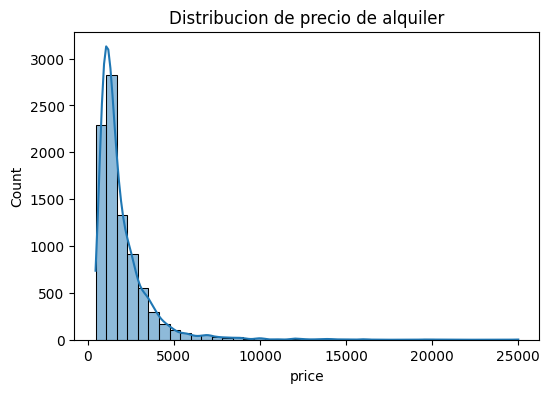

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib.util

# =====================================================================
# Histograma de precios del dataset completo
# =====================================================================
# Visualizacion rapida de la distribucion general de precios.
# La curva KDE superpuesta facilita ver la forma de la distribucion.
if "price" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df["price"].dropna(), bins=40, kde=True)
    plt.title("Distribucion de precio de alquiler")
    plt.show()

# =====================================================================
# Mapa interactivo con capas multiples
# =====================================================================
# Si Plotly esta disponible, se genera un mapa interactivo con:
#   - Anuncios: puntos coloreados por precio (escala Viridis)
#   - Barrios: centros de barrios (naranja) si hay datos de barriosMadrid.json
#   - Clusters: mismos puntos coloreados por cluster (escala Turbo)
#   - Oportunidades: puntos rojos destacando pisos infrapreciados
# Si Plotly no esta disponible, se usa folium como fallback.

lat_col = next((c for c in df.columns if "lat" in c.lower()), None)
lon_col = next((c for c in df.columns if "lon" in c.lower() or "lng" in c.lower()), None)

if importlib.util.find_spec("plotly") and lat_col and lon_col:
    import plotly.graph_objects as go
    use_scattermap = hasattr(go, "Scattermap")
    trace_cls = go.Scattermap if use_scattermap else go.Scattermapbox
    layout_key = "map" if use_scattermap else "mapbox"

    fig = go.Figure()
    sample = df.sample(min(3000, len(df)), random_state=SEED)

    # Capa 1: Anuncios coloreados por precio
    fig.add_trace(trace_cls(
        lat=sample[lat_col],
        lon=sample[lon_col],
        mode="markers",
        marker=dict(size=5, color=sample.get("price", None), colorscale="Viridis", showscale=True),
        name="anuncios",
    ))

    # Capa 2: Centros de barrios (si hay datos)
    if barrios_df is not None and {"lat", "lng"}.issubset(barrios_df.columns):
        fig.add_trace(trace_cls(
            lat=barrios_df["lat"],
            lon=barrios_df["lng"],
            mode="markers",
            marker=dict(size=6, color="orange"),
            name="barrios",
        ))

    # Capa 3: Clusters (mismos puntos, coloreados por cluster)
    if "cluster" in df.columns:
        fig.add_trace(trace_cls(
            lat=sample[lat_col],
            lon=sample[lon_col],
            mode="markers",
            marker=dict(size=5, color=sample["cluster"], colorscale="Turbo"),
            name="clusters",
        ))

    # Capa 4: Top oportunidades (pisos infrapreciados, en rojo)
    if opps_df is not None:
        for id_col in ["id", "url", "listing_fingerprint"]:
            if id_col in df.columns and id_col in opps_df.columns:
                opps = df.merge(opps_df, on=id_col, how="inner")
                fig.add_trace(trace_cls(
                    lat=opps[lat_col],
                    lon=opps[lon_col],
                    mode="markers",
                    marker=dict(size=8, color="red"),
                    name="oportunidades",
                ))
                break

    fig.update_layout(**{layout_key: dict(style="open-street-map")}, height=600, margin={"l":0, "r":0, "t":0, "b":0})
    fig.show()
elif lat_col and lon_col:
    # Fallback a folium si Plotly no esta disponible
    plot_maps(df.sample(min(5000, len(df))), lat_col, lon_col, value_col="price" if "price" in df.columns else None)


In [6]:
# =====================================================================
# Mapa Folium con capas de enriquecimiento (Metro + BiciMAD)
# =====================================================================
# Este mapa muestra la infraestructura de transporte superpuesta con
# los anuncios de alquiler:
#   - Circulos azules: anuncios (muestra de 2000)
#   - Circulos rojos: estaciones de Metro
#   - Circulos verdes: estaciones de BiciMAD
# La proximidad a transporte publico es una de las features mas
# importantes del modelo enriquecido (NB09).

import importlib.util as _iu
if _iu.find_spec("folium") and lat_col and lon_col:
    import folium
    center_lat = df[lat_col].median()
    center_lon = df[lon_col].median()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

    # Capa: muestra de anuncios
    sample_f = df.sample(min(2000, len(df)), random_state=SEED)
    for _, row in sample_f.iterrows():
        folium.CircleMarker(
            [row[lat_col], row[lon_col]], radius=2, color="blue", fill=True,
        ).add_to(m)

    # Capa: estaciones de Metro (convertir UTM a WGS84 si es necesario)
    metro_path = ROOT / "data" / "external" / "mobility" / "metro_features.json"
    if metro_path.exists():
        metro_data = json.loads(metro_path.read_text(encoding="utf-8"))
        metro_features = metro_data if isinstance(metro_data, list) else metro_data.get("features", [])
        try:
            from pyproj import Transformer
            _utm_to_wgs = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)
            _has_pyproj = True
        except ImportError:
            _has_pyproj = False
        for feat in metro_features[:200]:
            geom = feat.get("geometry", {})
            props = feat.get("attributes", feat.get("properties", {}))
            if geom.get("y") and geom.get("x"):
                mx, my = geom["x"], geom["y"]
                if _has_pyproj:
                    mlon, mlat = _utm_to_wgs.transform(mx, my)
                else:
                    mlon, mlat = mx, my
                folium.CircleMarker(
                    [mlat, mlon], radius=4, color="red", fill=True,
                    popup=str(props.get("DENOMINACION", "Metro")),
                ).add_to(m)

    # Capa: estaciones de BiciMAD
    bicimad_path = ROOT / "data" / "external" / "mobility" / "bicimad.geojson"
    if bicimad_path.exists():
        bicimad = json.loads(bicimad_path.read_text(encoding="utf-8"))
        for feat in bicimad.get("features", [])[:200]:
            coords = feat.get("geometry", {}).get("coordinates", [])
            if len(coords) >= 2:
                folium.CircleMarker(
                    [coords[1], coords[0]], radius=3, color="green", fill=True,
                    popup=feat.get("properties", {}).get("name", "BiciMAD"),
                ).add_to(m)

    display(m)


**Outputs esperados**
- Prediccion puntual + intervalo (si hay cuantiles).
- Narrativa con drivers principales.
- Controles para activar/desactivar variables en la prediccion.


In [7]:
from IPython.display import display, Markdown

# --- Cargar metricas reales de los CSVs generados por notebooks anteriores ---
_ho = pd.read_csv(ROOT / "reports" / "holdout_metrics.csv")
_bl = pd.read_csv(ROOT / "reports" / "baselines_metrics.csv")
_uc = pd.read_csv(ROOT / "reports" / "uncertainty_metrics.csv")
_hp = json.load(open(ROOT / "reports" / "best_hyperparams.json"))
_hp_clean = {k.replace("model__", ""): v for k, v in _hp.items()}

# Extraer metricas de price
_p_ho = _ho[_ho["target"] == "price"].iloc[0]
_p_uc = _uc[_uc["target"] == "price"].iloc[0]
_rf_bl = _bl[(_bl["target"] == "price") & (_bl["model"] == "rf")].iloc[0]
_rf_pm2 = _bl[(_bl["target"] == "price_m2") & (_bl["model"] == "rf")]
_rf_pm2_mae = f"{_rf_pm2.iloc[0]['mae']:.2f}" if not _rf_pm2.empty else "N/A"

_pm2_ho = _ho[_ho["target"] == "price_m2"].iloc[0] if "price_m2" in _ho["target"].values else None
_pm2_ho_mae = f"{_pm2_ho['mae']:.2f}" if _pm2_ho is not None else "N/A"
_pm2_ho_r2 = f"{_pm2_ho['r2']:.3f}" if _pm2_ho is not None else "N/A"

# Enrichment
_ei_path = ROOT / "reports" / "enrichment_impact.md"
_ei_delta = "N/A"
if _ei_path.exists():
    for line in _ei_path.read_text(encoding="utf-8").split("\n"):
        if line.startswith("- Delta:"):
            _ei_delta = line.replace("- Delta: ", "")

# CQR
_cqr_cov = f"{_p_uc['coverage_holdout_adj_raw']*100:.1f}%"
_cqr_width = f"{_p_uc['avg_width_holdout_adj_raw']:.0f}"

# Percentiles (ya calculados en celda anterior)
_pcts = features_df["price"].quantile([0.1, 0.5, 0.9]).to_dict()

_hp_str = ", ".join(f"{k}={v}" for k, v in _hp_clean.items())


# Top-3 SHAP reales (target price)
_fi_global_path = ROOT / "reports" / "feature_importances.csv"
_top3_text = "N/A"
if _fi_global_path.exists():
    _fi_global = pd.read_csv(_fi_global_path)
    if "Unnamed: 0" in _fi_global.columns:
        _fi_global = _fi_global.rename(columns={"Unnamed: 0": "feature"})
    if "feature" in _fi_global.columns and not _fi_global.empty:
        _top3 = _fi_global["feature"].head(3).tolist()
        _top3_text = ", ".join(_top3)

# Conteo de features de enrichment usado en auditoria
_enrich_n = "N/A"
if _ei_path.exists():
    for line in _ei_path.read_text(encoding="utf-8").split("\n"):
        if line.startswith("- Features enrichment:"):
            _enrich_n = line.split(":", 1)[1].strip()

md = f"""---

## Conclusiones del Dashboard y del proyecto completo

### Componentes del Dashboard MVP

| Componente | Tecnologia | Que hace |
|-----------|------------|----------|
| **Estimador de precio** | ipywidgets | Prediccion puntual + intervalo calibrado (P5-P95) |
| **Explicacion de drivers** | SHAP / fallback heuristico | Drivers principales arriba/abajo |
| **Mapa multicapa** | Plotly + Folium | Anuncios, barrios, clusters, oportunidades, movilidad |
| **Comparadores** | pandas | Percentiles por distrito y globales |

### Modelo en uso

| Parametro | Valor |
|-----------|-------|
| **Motor** | CatBoost |
| **Holdout MAE** | {_p_ho['mae']:.2f} EUR |
| **Holdout R2** | {_p_ho['r2']:.3f} |
| **Mejores hiperparametros** | {_hp_str} |
| **Intervalo calibrado** | Cobertura holdout {_cqr_cov} (CQR raw), anchura {_cqr_width} EUR |

### Percentiles globales (dataset actual)

- P10: {_pcts.get(0.1, 0):,.0f} EUR/mes
- P50: {_pcts.get(0.5, 0):,.0f} EUR/mes
- P90: {_pcts.get(0.9, 0):,.0f} EUR/mes

---

### Resumen ejecutivo NB01 -> NB11

| Notebook | Resultado clave |
|----------|------------------|
| **01** | Dataset limpio ({len(features_df):,} anuncios) + holdout por staleness + validacion price_m2 |
| **02** | EDA dual target (price + price_m2) + figuras guardadas |
| **03** | Features Master: {len(features_df.columns)} cols (core + {_enrich_n} enrichment + VUT) |
| **04** | Baselines: RF mejor (MAE {_rf_bl['mae']:.2f} EUR price, {_rf_pm2_mae} EUR/m2 price_m2) |
| **05** | CatBoost: MAE {_p_ho['mae']:.2f} EUR (price), {_pm2_ho_mae} EUR/m2 (price_m2), R2 {_p_ho['r2']:.3f} |
| **06** | SHAP (price) top-3: {_top3_text} |
| **07** | CQR dual target + P50 clipping: cobertura holdout {_cqr_cov}, anchura {_cqr_width} EUR |
| **08** | Clusters + scoring dual (price + price_m2) + oportunidades |
| **09** | Enrichment audit: {_ei_delta} |
| **10** | Features temporales (independientes del modelo principal) |
| **11** | Dashboard MVP interactivo (modelo operativo: target price) |

### Limitaciones conocidas

1. **Split por staleness (no temporal puro)**: `last_update` refleja la fecha de refresco del anuncio, no de publicacion. Genera distribution shift favorable en holdout.
2. **Cobertura CQR {"< 85%" if _p_uc['coverage_holdout_adj_raw'] < 0.85 else ">= 85%"}**: Los intervalos cubren {_cqr_cov} en holdout para price.
3. **price_m2 mas dificil de predecir**: R2 = {_pm2_ho_r2} (vs {_p_ho['r2']:.3f} para price) — factores cualitativos no observados.
4. **VUT sin features espaciales completas**: Depende de disponibilidad del SHP con coordenadas.
5. **Temporalidad limitada**: Solo dia/mes sin anio en datos crudos — asumimos anio de ejecucion.
"""
display(Markdown(md))

---

## Conclusiones del Dashboard y del proyecto completo

### Componentes del Dashboard MVP

| Componente | Tecnologia | Que hace |
|-----------|------------|----------|
| **Estimador de precio** | ipywidgets | Prediccion puntual + intervalo calibrado (P5-P95) |
| **Explicacion de drivers** | SHAP / fallback heuristico | Drivers principales arriba/abajo |
| **Mapa multicapa** | Plotly + Folium | Anuncios, barrios, clusters, oportunidades, movilidad |
| **Comparadores** | pandas | Percentiles por distrito y globales |

### Modelo en uso

| Parametro | Valor |
|-----------|-------|
| **Motor** | CatBoost |
| **Holdout MAE** | 301.31 EUR |
| **Holdout R2** | 0.804 |
| **Mejores hiperparametros** | iterations=4997, depth=8, learning_rate=0.29915045507974913, l2_leaf_reg=0.015088745786191366, random_strength=14.983514265381537, min_data_in_leaf=17, border_count=56, od_wait=73, model_size_reg=8.254333438517223, leaf_estimation_iterations=15, rsm=0.6101741207485138, grow_policy=Depthwise, bootstrap_type=MVS, subsample=0.9686170013692436, sampling_frequency=PerTree, od_type=Iter |
| **Intervalo calibrado** | Cobertura holdout 85.3% (CQR raw), anchura 1358 EUR |

### Percentiles globales (dataset actual)

- P10: 850 EUR/mes
- P50: 1,450 EUR/mes
- P90: 3,550 EUR/mes

---

### Resumen ejecutivo NB01 -> NB11

| Notebook | Resultado clave |
|----------|------------------|
| **01** | Dataset limpio (8,797 anuncios) + holdout por staleness + validacion price_m2 |
| **02** | EDA dual target (price + price_m2) + figuras guardadas |
| **03** | Features Master: 70 cols (core + 15 enrichment + VUT) |
| **04** | Baselines: RF mejor (MAE 332.18 EUR price, 3.91 EUR/m2 price_m2) |
| **05** | CatBoost: MAE 301.31 EUR (price), 3.16 EUR/m2 (price_m2), R2 0.804 |
| **06** | SHAP (price) top-3: surface_m2, bathrooms, floor_built |
| **07** | CQR dual target + P50 clipping: cobertura holdout 85.3%, anchura 1358 EUR |
| **08** | Clusters + scoring dual (price + price_m2) + oportunidades |
| **09** | Enrichment audit: 0.53 EUR (0.2% mejora) |
| **10** | Features temporales (independientes del modelo principal) |
| **11** | Dashboard MVP interactivo (modelo operativo: target price) |

### Limitaciones conocidas

1. **Split por staleness (no temporal puro)**: `last_update` refleja la fecha de refresco del anuncio, no de publicacion. Genera distribution shift favorable en holdout.
2. **Cobertura CQR >= 85%**: Los intervalos cubren 85.3% en holdout para price.
3. **price_m2 mas dificil de predecir**: R2 = 0.587 (vs 0.804 para price) — factores cualitativos no observados.
4. **VUT sin features espaciales completas**: Depende de disponibilidad del SHP con coordenadas.
5. **Temporalidad limitada**: Solo dia/mes sin anio en datos crudos — asumimos anio de ejecucion.
